In [ ]:
'''import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


training_data = pd.read_csv(r"C:\Users\UAE\Downloads\Abdur Rafay\Datasets\Summarization Tool Dataset\samsum-train.csv")
test_data = pd.read_csv(r"C:\Users\UAE\Downloads\Abdur Rafay\Datasets\Summarization Tool Dataset\samsum-test.csv")

#training_data = training_data.dropna

def clean_tags(text):
    clean = re.compile('<.*?>') # Compiling tags
    clean = re.sub(clean, '', text) # Replacing tags text by an empty string

    # Removing empty dialogues
    clean = '\n'.join([line for line in clean.split('\n') if not re.match('.*:*$', line)])

    return clean

# Defining function to clean every text in the dataset.
def clean_df(df, cols):
    for col in cols:
        df[col] = df[col].fillna('').apply(clean_tags)
    return df

training_data = clean_df(training_data,['dialogue', 'summary'])

dialogues = training_data['dialogue'].values[:1000]
summaries = training_data['summary'].values[:1000]

tokenizer_dialogue = Tokenizer()
tokenizer_summary = Tokenizer()

tokenizer_dialogue.fit_on_texts(dialogues)
tokenizer_summary.fit_on_texts(summaries)

dialogue_sequences = tokenizer_dialogue.texts_to_sequences(dialogues)
summary_sequences = tokenizer_summary.texts_to_sequences(summaries)

max_dialogue_length = max(len(seq) for seq in dialogue_sequences)
max_summary_length = max(len(seq) for seq in summary_sequences)

dialogue_sequences_padded = pad_sequences(dialogue_sequences, maxlen = max_dialogue_length, padding='post')
summary_sequences_padded = pad_sequences(summary_sequences, maxlen = max_summary_length, padding='post')

vocab_size_dialogue = len(tokenizer_dialogue.word_index) + 1
vocab_size_summary = len(tokenizer_summary.word_index) + 1
embedding_dim=100
latent_dim=256

encoder_inputs=Input(shape=(max_dialogue_length,))
encoder_embedding=Embedding(input_dim=vocab_size_dialogue, output_dim=embedding_dim)(encoder_inputs)
encoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
encoder_outputs, state_c, state_h=encoder_lstm(encoder_embedding)
encoder_states=[state_h, state_c]

decoder_inputs=Input(shape=(None,))
decoder_embedding=Embedding(input_dim=vocab_size_summary, output_dim=embedding_dim)(decoder_inputs)
decoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
decoder_outputs, state_h_d, state_c_d=decoder_lstm(encoder_embedding, initial_state=encoder_states)

attention_layer=Attention()([decoder_outputs, encoder_outputs])
decoder_concat_input=Concatenate(axis=1)([decoder_outputs, attention_layer])

decoder_dense=Dense(vocab_size_summary, activation='softmax')
decoder_outputs_final=decoder_dense(decoder_concat_input)

model=Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history=model.fit([dialogue_sequences_padded, np.roll(summary_sequences_padded, -1, axis=1)], np.expand_dims(summary_sequences_padded, -1), batch_size=64, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

encoder_model=Model(encoder_inputs, [encoder_outputs, state_h, state_c])
decoder_state_input_h=Input(shape=(latent_dim,))
decoder_state_input_c=Input(shape=(latent_dim,))
decoder_hidden_state_input=Input(shape=(max_dialogue_length, latent_dim))

decoder_outputs_inference, state_h_inference, state_c_inference=decoder_lstm(decoder_embedding, initial_state=[decoder_state_input_h, decoder_state_input_c])
attention_output_inference=Attention()([decoder_outputs_inference, decoder_hidden_state_input])
decoder_concat_input_inference = Concatenate(axis=-1)([decoder_outputs_inference, attention_output_inference])
decoder_outputs_final_inference=decoder_dense(decoder_concat_input_inference)


decoder_model=Model([decoder_inputs, decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c], [decoder_outputs_final_inference, state_h_inference, state_c_inference])

def generate_summary(input_text):
    input_seq=tokenizer_dialogue.texts_to_sequences([input_text])
    input_seq_padded=pad_sequences(input_seq, maxlen=max_dialogue_length, padding='post')
    
    encoder_outputs_value, state_h, state_c=encoder_model.predict(input_seq_padded)
    states_value=[state_h, state_c]

    target_seq=np.zeros((1, 1))
    target_seq[0, 0]=tokenizer_summary.word_index.get('startseq', 1)

    decoded_sentence=''

for _ in range(max_summary_length):
    output_tokens, h, c = decoder_model.predict([target_seq, encoder_outputs_value, states_value[0], states_value[1]])



    sampled_token_index=np.argmax(output_tokens[0, -1, :])
    sampled_word=tokenizer_summary.index_word.get[sampled_token_index, '']

    if sampled_word=='endseq' or sampled_word=='':
        break

    decoded_sentence += ' ' + sampled_word

    target_seq=np.zeros((1, 1))
    target_seq[0, 0]=sampled_token_index

    states_value=[h, c]

    return decoded_sentence.strip()'''

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, Attention
from tensorflow.keras.models import Model
#from tensorflow.keras.callbacks import EarlyStopping

In [21]:
training_data = pd.read_csv(r"C:\Users\UAE\Downloads\Abdur Rafay\Datasets\Summarization Tool Dataset\samsum-train.csv")
test_data = pd.read_csv(r"C:\Users\UAE\Downloads\Abdur Rafay\Datasets\Summarization Tool Dataset\samsum-test.csv")

#training_data = training_data.dropna

def clean_tags(text):
    clean = re.compile('<.*?>') # Compiling tags
    clean = re.sub(clean, '', text) # Replacing tags text by an empty string

    # Removing empty dialogues
    clean = '\n'.join([line for line in clean.split('\n') if not re.match('.*:*$', line)])

    return clean

# Defining function to clean every text in the dataset.
def clean_df(df, cols):
    for col in cols:
        df[col] = df[col].fillna('').apply(clean_tags)
    return df

#training_data = clean_df(training_data,['dialogue', 'summary'])

In [22]:
dialogues = training_data['dialogue'].values[:1000]
summaries = training_data['summary'].values[:1000]

tokenizer_dialogue = Tokenizer()
tokenizer_summary = Tokenizer()

tokenizer_dialogue.fit_on_texts(dialogues)
tokenizer_summary.fit_on_texts(summaries)

dialogue_sequences = tokenizer_dialogue.texts_to_sequences(dialogues)
summary_sequences = tokenizer_summary.texts_to_sequences(summaries)

max_dialogue_length = max(len(seq) for seq in dialogue_sequences)
max_summary_length = max(len(seq) for seq in summary_sequences)

dialogue_sequences_padded = pad_sequences(dialogue_sequences, maxlen = max_dialogue_length, padding='post')
summary_sequences_padded = pad_sequences(summary_sequences, maxlen = max_summary_length, padding='post')

vocab_size_dialogue = len(tokenizer_dialogue.word_index) + 1
vocab_size_summary = len(tokenizer_summary.word_index) + 1
embedding_dim=100
latent_dim=256

In [23]:
encoder_inputs=Input(shape=(max_dialogue_length,))
encoder_embedding=Embedding(input_dim=vocab_size_dialogue, output_dim=embedding_dim)(encoder_inputs)
encoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
encoder_outputs, state_c, state_h=encoder_lstm(encoder_embedding)
encoder_states=[state_h, state_c]

decoder_inputs=Input(shape=(None,))
decoder_embedding=Embedding(input_dim=vocab_size_summary, output_dim=embedding_dim)(decoder_inputs)
decoder_lstm=LSTM(latent_dim, return_state=True, return_sequences=True)
decoder_outputs, state_h_d, state_c_d=decoder_lstm(decoder_embedding, initial_state=encoder_states)

attention_layer=Attention()([decoder_outputs, encoder_outputs])
decoder_concat_input=Concatenate(axis=-1)([decoder_outputs, attention_layer])

decoder_dense=Dense(vocab_size_summary, activation='softmax')
decoder_outputs_final=decoder_dense(decoder_concat_input)

model=Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history=model.fit([dialogue_sequences_padded, np.roll(summary_sequences_padded, -1, axis=1)], summary_sequences_padded, batch_size=64, epochs=10, validation_split=0.2) #callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5053 - loss: 6.6110 - val_accuracy: 0.6412 - val_loss: 3.1523
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6487 - loss: 2.8861 - val_accuracy: 0.6412 - val_loss: 2.5489
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6507 - loss: 2.3893 - val_accuracy: 0.6413 - val_loss: 2.5088
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6657 - loss: 2.2761 - val_accuracy: 0.6545 - val_loss: 2.5057
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6607 - loss: 2.3380 - val_accuracy: 0.6545 - val_loss: 2.5101
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.6662 - loss: 2.2820 - val_accuracy: 0.6556 - val_loss: 2.5126
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6679 - loss: 2.2579 - val_accuracy: 0.6582 - val_loss: 2.5140
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.6606 - loss: 2.2822 - val_accuracy: 0.6531 - val_loss:

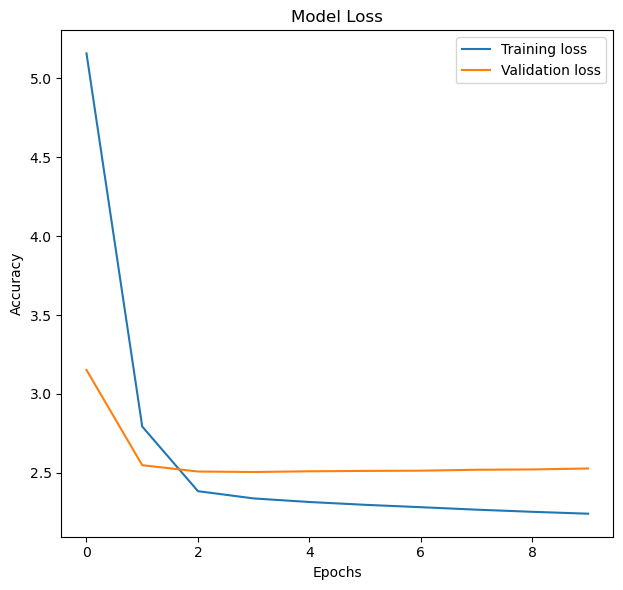

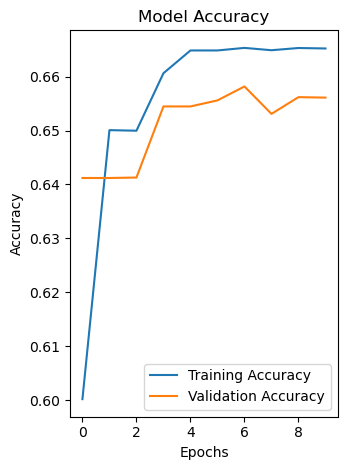

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
encoder_model=Model(encoder_inputs, [encoder_outputs, state_h, state_c])
decoder_state_input_h=Input(shape=(latent_dim,))
decoder_state_input_c=Input(shape=(latent_dim,))
decoder_hidden_state_input=Input(shape=(max_dialogue_length, latent_dim))

decoder_outputs_inference, state_h_inference, state_c_inference=decoder_lstm(decoder_embedding, initial_state=[decoder_state_input_h, decoder_state_input_c])
attention_output_inference=Attention()([decoder_outputs_inference, decoder_hidden_state_input])
decoder_concat_input_inference = Concatenate(axis=-1)([decoder_outputs_inference, attention_output_inference])
decoder_outputs_final_inference=decoder_dense(decoder_concat_input_inference)


decoder_model=Model([decoder_inputs, decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c], [decoder_outputs_final_inference, state_h_inference, state_c_inference])

In [ ]:
def generate_summary(input_text):
    # Tokenize & pad input text
    input_seq = tokenizer_dialogue.texts_to_sequences([input_text])
    input_seq_padded = pad_sequences(input_seq, maxlen=max_dialogue_length, padding='post')

    # Encode input
    encoder_out, state_h, state_c = encoder_model.predict(input_seq_padded)
    states_value = [state_h, state_c]

    # Start token (adjust if not using 'startseq')
    target_seq = np.zeros((1, 1))
    start_token = tokenizer_summary.word_index.get('startseq', 1)  # Default to 1 if 'startseq' not found
    target_seq[0, 0] = start_token

    decoded_sentence = ''

    for _ in range(max_summary_length):
        output_tokens, h, c = decoder_model.predict([target_seq, encoder_out, states_value[0], states_value[1]])

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = tokenizer_summary.index_word.get(sampled_token_index, '')

        if sampled_word == 'endseq' or sampled_word == '':
            break

        decoded_sentence += ' ' + sampled_word

        # Update target sequence with last predicted word
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        states_value = [h, c]

    return decoded_sentence.strip()

In [35]:
test_dialogue = test_data['dialogue'].iloc[0]
actual_summary = test_data['summary'].iloc[0]

# Print original and actual
print("Original Dialogue:\n", test_dialogue)
print("\nActual Summary:\n", actual_summary)

# Generate predicted summary
generated_summary = generate_summary(test_dialogue)
print("\nGenerated Summary:\n", generated_summary)

Original Dialogue:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Actual Summary:
 Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━